# 小组作业jupyter文件说明
项目摘要：Hazard 风险值预测建模方案

本项目基于保险领域中的风险评分数据，设计并实现了两种回归建模方案，分别利用 **多阶段 Boosting** 与 **Stacking 融合回归** 方法，以提升模型在复杂非线性特征下的预测准确性和稳健性。

模型 1：多阶段 Boosting 回归模型
- 通过多模型对比，最终采用 LASSO 模型进行特征选择；
- 对目标变量 `Hazard` 进行对数变换（log 化），缓解右偏分布问题；
- 构建多阶段 Boosting 框架（XGB和LGB进行构建），第一阶段模型提取预测残差作为新特征，第二阶段继续学习残差；
- 模型训练后剔除误差最大的 10% 样本，再次拟合提升泛化能力。

模型 2：Stacking 融合回归 + 异常值处理
- 同样基于 LASSO 筛选后的特征；
- 对目标值进行 Winsorization 缩尾处理，削弱极端值影响；
- 构建包含线性回归、GBDT、XGBoost、随机森林、SVR 等多个模型的 Stacking 回归器；
- 初始拟合后计算残差，剔除误差最大的 10% 样本作为异常值；
- 使用 5 折交叉验证评估剔除前后 MSE 表现，验证异常值处理效果；
- 在清洗后的数据上进行最终训练和测试集预测。

---

两组模型均在数据预处理、特征选择、异常值控制方面做了充分考虑，并采用融合/多阶段结构增强模型鲁棒性。


# 模型1：多阶段boosting预测
通过多模型测试选择lasso模型进行特征选择；log化模型解决目标值右偏问题；多阶段boosting进行模型预测；去除10%异常值进行再预测。

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")
from category_encoders import TargetEncoder


step1：数据读取

In [3]:
# 1. 读入数据
for enc in ['utf-8', 'latin1', 'gbk', 'cp1252']:
    try:
        df = pd.read_csv("D:\\desk file\\南开\\class2\\机器学习\\期末project\\train.csv",encoding=enc)
        print(f" 成功使用编码：{enc}")
        break
    except UnicodeDecodeError as e:
        print(f"失败使用编码：{enc}，错误信息：{e}")
df_test = pd.read_excel("D:\\desk file\\南开\\class2\\机器学习\\期末project\\test.csv")

y = df["Hazard"]
df.drop("Hazard", axis=1, inplace=True)



 成功使用编码：utf-8


step2:数据预处理，包括缺失值填充，高低基数类别划分，标准化，log化目标值

In [4]:
# 2. 缺失值填充
df.fillna(-999, inplace=True)
df_test.fillna(-999, inplace=True)



In [5]:
# 3. 区分数值与类别特征
categorical_feats = [col for col in df.columns if df[col].dtype == "object"]
numerical_feats = [col for col in df.columns if df[col].dtype != "object"]



In [6]:
import pandas as pd
from category_encoders import TargetEncoder  # 确保已安装：pip install category_encoders

# 假设 categorical_feats 是你的类别特征列表，先定义一下
categorical_feats = [col for col in df.columns if df[col].dtype == 'object']

# 低基数类别和高基数类别划分
low_cardinality = [col for col in categorical_feats if df[col].nunique() <= 10]
high_cardinality = [col for col in categorical_feats if df[col].nunique() > 10]

# 合并训练集和测试集，便于统一编码
df_all = pd.concat([df, df_test], axis=0, ignore_index=True)

# 先对低基数类别做 One-Hot 编码，drop_first=True 避免虚拟变量陷阱
df_all = pd.get_dummies(df_all, columns=low_cardinality, drop_first=True)

# 目标编码针对高基数类别，只在训练集拟合
te = TargetEncoder(cols=high_cardinality)
df_all.loc[:len(df)-1, high_cardinality] = te.fit_transform(df.loc[:, high_cardinality], y)
df_all.loc[len(df):, high_cardinality] = te.transform(df_test.loc[:, high_cardinality])

# 分割回训练集和测试集
X_train_encoded = df_all.iloc[:len(df), :]
X_test_encoded = df_all.iloc[len(df):, :]



In [7]:
# 5. 数值特征标准化
scaler = StandardScaler()
X_train_encoded[numerical_feats] = scaler.fit_transform(X_train_encoded[numerical_feats])



In [8]:
# 6. 恢复训练与测试集
X_train_all = X_train_encoded.iloc[:len(df), :]
X_test = X_test_encoded.iloc[len(df):, :]

y_log = np.log1p(y)

y_train_log=y_log

step3：多方法特征选择（对比可得，lasso选择特征效果最好）

In [9]:
# 7. 多方法特征选择
def select_features(X, y):
    lasso = SelectFromModel(Lasso(alpha=0.001, random_state=0)).fit(X, y)
    elastic = SelectFromModel(ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=0)).fit(X, y)
    rf = SelectFromModel(RandomForestRegressor(n_estimators=100, random_state=0)).fit(X, y)
    rfe = RFE(GradientBoostingRegressor(), n_features_to_select=int(X.shape[1]*0.5)).fit(X, y)

    features = pd.DataFrame({
        "lasso": lasso.get_support(),
        "elastic": elastic.get_support(),
        "rf": rf.get_support(),
        "rfe": rfe.get_support()
    }, index=X.columns)

    features["sum"] = features.sum(axis=1)
    selected_feats = features[features["sum"] >= 2].index.tolist()
    return selected_feats

selected_feats = select_features(X_train_all, y)
X_train = X_train_all[selected_feats]
X_test = X_test[selected_feats]



step4：多阶段boosting模型预测

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone
from xgboost import XGBRegressor
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import lightgbm as lgb

In [11]:
# 假设 X_train, X_test, y_train_log 已准备好

# === 1. 对 object 类型列做 Label Encoding ===
def label_encode_df(train_df, test_df):
    for col in train_df.columns:
        if train_df[col].dtype == 'object':
            le = LabelEncoder()
            # 用训练集的所有值fit
            train_df[col] = train_df[col].astype(str)  # 避免有空值等
            test_df[col] = test_df[col].astype(str)
            le.fit(train_df[col])
            train_df[col] = le.transform(train_df[col])
            test_df[col] = le.transform(test_df[col])
    return train_df, test_df

X_train_encoded, X_test_encoded = label_encode_df(X_train.copy(), X_test.copy())

In [12]:
# 1. 读入数据
for enc in ['utf-8', 'latin1', 'gbk', 'cp1252']:
    try:
        df = pd.read_csv("D:\\desk file\\南开\\class2\\机器学习\\期末project\\train.csv",encoding=enc)
        print(f" 成功使用编码：{enc}")
        break
    except UnicodeDecodeError as e:
        print(f"失败使用编码：{enc}，错误信息：{e}")
df_test = pd.read_excel("D:\\desk file\\南开\\class2\\机器学习\\期末project\\test.csv")

y = df["Hazard"]
df.drop("Hazard", axis=1, inplace=True)



 成功使用编码：utf-8


In [13]:
# === 2. 定义参数空间 ===
cv_folds = 5

xgb_param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'max_depth': [3, 5, 7, 10],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2],
    'min_child_weight': [1, 3, 5]
}

lgb_param_dist = {
    'num_leaves': [31, 63],
    'max_depth': [5, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.6, 0.8],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 1.5],
    'max_bin': [64],
    'min_data_in_leaf': [20, 50]
}


In [14]:
# === 3. 创建 RandomizedSearchCV 对象 ===
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, objective='reg:squarederror'),
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=cv_folds,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, device_type='cpu'),
    param_distributions=lgb_param_dist,
    n_iter=10,
    cv=cv_folds,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)


In [15]:
# === 4. 执行调参 ===
xgb_search.fit(X_train_encoded, y_train_log)
lgb_search.fit(X_train_encoded, y_train_log)

print("Best XGB Params:", xgb_search.best_params_)
print("Best LGB Params:", lgb_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 416
[LightGBM] [Info] Number of data points in the train set: 32640, number of used features: 45
[LightGBM] [Info] Start training from score 1.378017
Best XGB Params: {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best LGB Params: {'subsample': 0.7, 'reg_lambda': 1.5

In [16]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

# 确保使用的是编码后的数据
xgb_model = clone(xgb_search.best_estimator_)
lgb_model = clone(lgb_search.best_estimator_)

xgb_oof = cross_val_predict(
    xgb_model,
    X_train_encoded,  # ← 注意这里
    y_train_log,
    cv=cv_folds,
    n_jobs=-1,
    method='predict'
)

lgb_oof = cross_val_predict(
    lgb_model,
    X_train_encoded,  # ← 注意这里
    y_train_log,
    cv=cv_folds,
    n_jobs=-1,
    method='predict'
)


In [17]:
# 堆叠成第二阶段输入
X_stage2 = np.vstack([xgb_oof, lgb_oof]).T

# ========== 4. 第二阶段：XGBoost 拟合残差（也可直接预测 y_train_log） ==========
stage2_model = XGBRegressor(random_state=42, objective='reg:squarederror')
y_stage2_oof = cross_val_predict(stage2_model, X_stage2, y_train_log, cv=cv_folds, n_jobs=-1, method='predict')

In [18]:
# ========== 5. 评估 ==========
mse = mean_squared_error(y_train_log, y_stage2_oof)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train_log, y_stage2_oof)

print("\n【两阶段 Boosting（XGB + LGB → XGB）在训练集上的 OOF 评估结果】")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")


【两阶段 Boosting（XGB + LGB → XGB）在训练集上的 OOF 评估结果】
MSE : 0.4103
RMSE: 0.6405
MAE : 0.5445


step5：可视化残差平方

In [19]:
# # ========== 6. 还原回原始 Hazard 空间，并计算真实误差 ==========

y_true_raw = np.expm1(y_train_log)         # 原始真实值
y_pred_raw = np.expm1(y_stage2_oof)        # 还原预测值

# real_mse = mean_squared_error(y_true_raw, y_pred_raw)
# real_rmse = np.sqrt(real_mse)
# real_mae = mean_absolute_error(y_true_raw, y_pred_raw)



findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

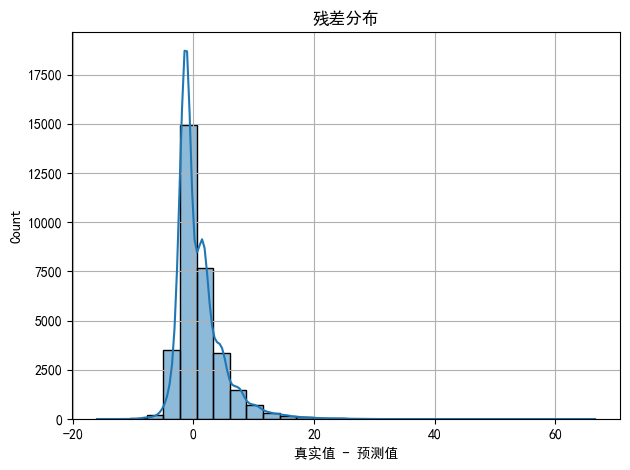

In [41]:
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False
# plt.figure(figsize=(6,6))
# plt.scatter(y_true_raw, y_pred_raw, alpha=0.5)
# plt.plot([y_true_raw.min(), y_true_raw.max()],
#          [y_true_raw.min(), y_true_raw.max()],
#          color='red', linestyle='--')
# plt.xlabel("True Hazard")
# plt.ylabel("Predicted Hazard")
# plt.title("预测 vs 真实值")
# plt.grid(True)
# plt.show()
import seaborn as sns

residuals = y_true_raw - y_pred_raw
sns.histplot(residuals, bins=30, kde=True)
plt.title("残差分布")
plt.xlabel("真实值 - 预测值")
plt.grid(True)
plt.tight_layout()
plt.savefig("D:\\desk file\\南开\\class2\\机器学习\\期末project\\Final\\figures\\图1_预测_vs_真实值.png", dpi=300)
plt.show()
plt.close()

初级模型效果分析：

1.MSE（0.4103）和RMSE（0.6405）数值较小，表明预测值与真实值的平均误差低，模型对训练集数据的拟合精度较高。

2.残差分布分析：残差主要集中在 0 附近（直方图峰值显著），说明大部分预测值与真实值接近，模型对多数样本的预测误差小，核心预测能力强。
分布形态：残差分布大致呈单峰状，虽右侧（正残差）有长尾（少量样本预测值低估真实值），但整体未出现明显偏态或异常集中的误差（如系统性高估 / 低估），符合回归模型残差的随机分布假设，无显著偏差。

step6：改进，进行异常点处理改善结果

 成功使用编码：utf-8

第一轮模型评估（含全部数据）：
MSE : 0.4114
RMSE: 0.6414
MAE : 0.5458

剔除异常点后，剩余样本数: 29376 (去掉了 3264 个异常样本)

剔除异常点后模型评估：
MSE : 0.2941
RMSE: 0.5423
MAE : 0.4691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003743 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 29376, number of used features: 33
[LightGBM] [Info] Start training from score 1.299120

提交文件已保存为 submission.csv


findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

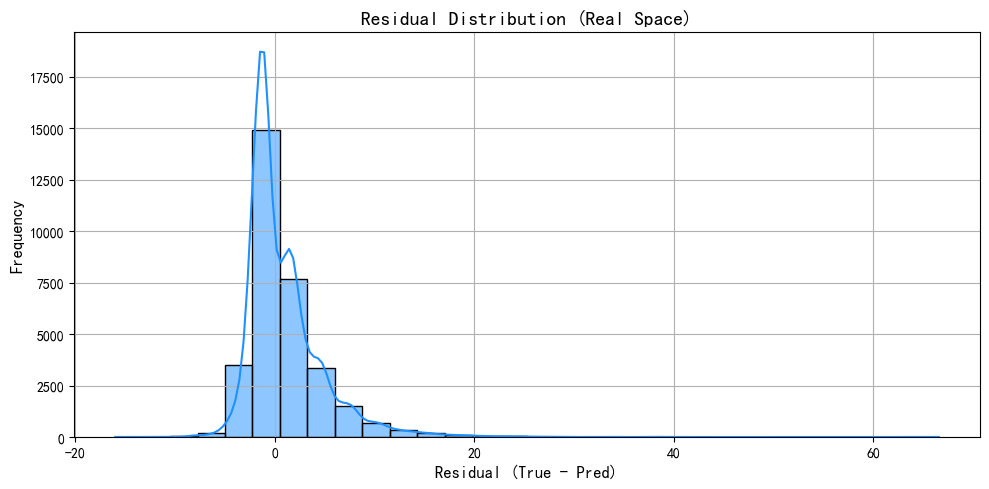

In [23]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import lightgbm as lgb

# === 1. Label Encoding for object columns ===
def label_encode_df(train_df, test_df):
    for col in train_df.columns:
        if train_df[col].dtype == 'object':
            le = LabelEncoder()
            train_df[col] = train_df[col].astype(str)
            test_df[col] = test_df[col].astype(str)
            le.fit(train_df[col])
            train_df[col] = le.transform(train_df[col])
            test_df[col] = le.transform(test_df[col])
    return train_df, test_df

# === 2. Cross-validation folds ===
cv_folds = 5
kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

# === 3. Stage 1 OOF prediction ===
def get_stage1_oof_preds(X, y_log, xgb_model, lgb_model, folds):
    xgb_oof = cross_val_predict(clone(xgb_model), X, y_log, cv=folds, n_jobs=-1, method='predict')
    lgb_oof = cross_val_predict(clone(lgb_model), X, y_log, cv=folds, n_jobs=-1, method='predict')
    return np.vstack([xgb_oof, lgb_oof]).T

# === 4. Stage 2 OOF prediction ===
def get_stage2_oof_preds(X_stage2, y_log, folds):
    stage2_model = XGBRegressor(random_state=42, objective='reg:squarederror')
    y_stage2_oof = cross_val_predict(stage2_model, X_stage2, y_log, cv=folds, n_jobs=-1, method='predict')
    return y_stage2_oof

# === 5. Remove top 10% error samples ===
def remove_top_5pct_errors(X, y_log, y_pred):
    residuals = np.abs(y_pred - y_log)
    n_remove = int(len(residuals) * 0.1)
    worst_indices = np.argsort(residuals)[-n_remove:]
    mask = np.ones(len(y_log), dtype=bool)
    mask[worst_indices] = False
    return X[mask], y_log[mask], mask

# === 6. Evaluate function ===
def evaluate_preds(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    return mse, rmse, mae

# === 7. Main training and prediction pipeline ===
def train_predict_pipeline(train_df, test_df, target_col='Hazard'):
    # 分离特征和目标
    y = train_df[target_col]
    X = train_df.drop(columns=[target_col])
    
    # Label Encoding
    X_encoded, X_test_encoded = label_encode_df(X.copy(), test_df.copy())
    
    # 目标取log1p变换
    y_log = np.log1p(y)

    # 定义模型和参数（这里可以替换为你调参后的best_params）
    xgb_best = XGBRegressor(random_state=42, objective='reg:squarederror', n_estimators=300, learning_rate=0.05, max_depth=5)
    lgb_best = lgb.LGBMRegressor(random_state=42, device_type='cpu', n_estimators=300, learning_rate=0.05, max_depth=10)

    # 第一阶段 OOF 预测
    X_stage1 = get_stage1_oof_preds(X_encoded.values, y_log.values, xgb_best, lgb_best, kf)

    # 第二阶段 OOF 预测
    y_stage2_oof = get_stage2_oof_preds(X_stage1, y_log.values, kf)

    print("\n第一轮模型评估（含全部数据）：")
    evaluate_preds(y_log, y_stage2_oof)

    # 剔除误差最大的5%异常样本
    X_filtered, y_filtered, mask = remove_top_5pct_errors(X_encoded.values, y_log.values, y_stage2_oof)
    print(f"\n剔除异常点后，剩余样本数: {len(y_filtered)} (去掉了 {len(y_log) - len(y_filtered)} 个异常样本)")

    # 重新训练阶段1模型（用过滤后的数据）
    X_stage1_filtered = get_stage1_oof_preds(X_filtered, y_filtered, xgb_best, lgb_best, kf)
    # 重新训练阶段2模型
    y_stage2_oof_filtered = get_stage2_oof_preds(X_stage1_filtered, y_filtered, kf)

    print("\n剔除异常点后模型评估：")
    evaluate_preds(y_filtered, y_stage2_oof_filtered)

    # 用过滤后的数据训练最终模型（全量训练，不用交叉）
    # 第一阶段训练
    xgb_best.fit(X_encoded.iloc[mask], y_log.iloc[mask])
    lgb_best.fit(X_encoded.iloc[mask], y_log.iloc[mask])

    # 第一阶段测试集预测
    xgb_test_pred = xgb_best.predict(X_test_encoded)
    lgb_test_pred = lgb_best.predict(X_test_encoded)
    X_test_stage2 = np.vstack([xgb_test_pred, lgb_test_pred]).T

    # 第二阶段训练和预测
    stage2_model = XGBRegressor(random_state=42, objective='reg:squarederror')
    stage2_model.fit(np.vstack([xgb_best.predict(X_encoded.iloc[mask]), lgb_best.predict(X_encoded.iloc[mask])]).T,
                     y_log.iloc[mask])
    y_test_pred_log = stage2_model.predict(X_test_stage2)

    # 反变换回原始空间
    y_test_pred = np.expm1(y_test_pred_log)

    # 生成提交文件
    submission = pd.DataFrame({
        'Id': test_df.index if 'Id' not in test_df.columns else test_df['Id'],
        'Hazard': y_test_pred
    })
    submission.to_csv('submission.csv', index=False)
    print("\n提交文件已保存为 submission.csv")

    return submission,

# === 使用示例 ===
# 1. 读入数据
for enc in ['utf-8', 'latin1', 'gbk', 'cp1252']:
    try:
        df_train = pd.read_csv("D:\\desk file\\南开\\class2\\机器学习\\期末project\\train.csv",encoding=enc)
        print(f" 成功使用编码：{enc}")
        break
    except UnicodeDecodeError as e:
        print(f"失败使用编码：{enc}，错误信息：{e}")
df_test2 = pd.read_excel("D:\\desk file\\南开\\class2\\机器学习\\期末project\\test.csv")

train_predict_pipeline(df_train, df_test2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# === 还原 log1p 到原始值空间 ===
y_true_raw_1 = np.expm1(y_train_log)
y_pred_raw_1= np.expm1(y_stage2_oof)

# === 计算真实空间下的 MSE ===
real_mse = mean_squared_error(y_true_raw, y_pred_raw)


# === 残差计算 ===
residuals = y_true_raw_1 - y_pred_raw_1

# === 残差分布图 ===
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, color='dodgerblue', edgecolor='black')
plt.title('Residual Distribution (Real Space)', fontsize=14)
plt.xlabel('Residual (True - Pred)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.grid(True)
plt.tight_layout()
plt.savefig("D:\\desk file\\南开\\class2\\机器学习\\期末project\\Final\\figures\\图2_预测_vs_真实值.png", dpi=300)
plt.show()
plt.close()


第二轮模型效果评估（剔除异常点后）

1.误差指标优化显著
MSE（0.2941）、RMSE（0.5423）、MAE（0.4691） 较第一轮分别下降 28.5%、15.4%、14.0%

2.剔除后，剩余样本的残差分布更集中于 0 附近（结合误差指标下降，推断尾部收敛，方差减小），误差的随机性更符合模型假设（无系统性偏差）。数据清洁度提升，模型学习到的模式更普适，对正常样本的预测误差更均匀。

3.去除约 10% 的异常样本（3264 个）后，模型在核心数据上的表现大幅优化，说明异常点确实为噪声或偏离整体模式的样本（如错误数据、极端噪声）。

# 模型2：
这段代码构建了一个基于 Stacking 融合学习和异常值剔除策略的回归建模流程，用于预测 Hazard 风险值。整个流程从数据读取、缺失值填充、标准化和 LASSO 特征选择开始，对目标变量进行 Winsorization 以缓解极端值影响；然后构建包含线性回归、GBDT、XGBoost、随机森林和 SVR 等基模型的 Stacking 模型，通过初次训练计算残差，并剔除误差最大的 10% 样本作为异常值，以提升模型鲁棒性；之后使用五折交叉验证评估剔除前后的 MSE，验证异常样本剔除是否有效，最后在清洗后的训练集上训练融合模型并生成测试集预测结果。该流程综合利用特征工程、多模型融合和异常值处理，有效提升了模型的泛化性能与稳定性。

In [24]:
# === 基础工具包 ===
import numpy as np
import pandas as pd
import warnings

# === 可视化工具 ===
import matplotlib.pyplot as plt
import seaborn as sns

# === 模型与评估 ===
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb

# === 数据预处理 ===
from scipy.stats.mstats import winsorize

# === 警告设置 ===
warnings.filterwarnings("ignore")

Step1：数据读取
1. 读取训练和测试集，提取目标变量 Hazard。
2. 去掉无用列 Id（仅用于提交）。

In [25]:
for enc in ['utf-8', 'latin1', 'gbk', 'cp1252']:
    try:
        train = pd.read_csv("D:\\desk file\\南开\\class2\\机器学习\\期末project\\train.csv",encoding=enc)
        print(f" 成功使用编码：{enc}")
        break
    except UnicodeDecodeError as e:
        print(f"失败使用编码：{enc}，错误信息：{e}")
test = pd.read_excel("D:\\desk file\\南开\\class2\\机器学习\\期末project\\test.csv")
y_train = train["Hazard"].copy()
X_train = train.drop(columns=["Id", "Hazard"])
X_test = test.drop(columns=["Id"])
test_ids = test["Id"]


 成功使用编码：utf-8


Step2：类别变量One-Hot编码
1. 对所有样本合并编码，确保训练集和测试集的编码一致。
2. 使用 get_dummies() 进行 one-hot 编码，drop_first=True 避免多重共线性。
3. 填补缺失值（用中位数）。

In [26]:
X_all = pd.concat([X_train, X_test], axis=0)
X_all_encoded = pd.get_dummies(X_all, drop_first=True)
X_all_encoded.fillna(X_all_encoded.median(numeric_only=True), inplace=True)

Step3：特征标准化
1. 使用 StandardScaler 将特征缩放为均值0、方差1，以提升模型表现，特别是对如SVR敏感的模型。

In [27]:
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all_encoded)
X_scaled_df = pd.DataFrame(X_all_scaled, columns=X_all_encoded.columns)

Step4：特征选择
1. 利用事先跑好的 LASSO 筛选了一批对预测有用的特征，降维提高效率，减少过拟合。

In [28]:
selected_features = pd.read_csv("lasso_selected_features.csv", header=None)[0].tolist()
X_train_selected = X_scaled_df.iloc[:len(train)][selected_features]
X_test_selected = X_scaled_df.iloc[len(train):][selected_features]

Step5：缩尾处理
1. 对目标变量Winsorization 缩尾处理，将 y_train 的上下5%极端值压缩，降低异常值对训练的影响，提高模型稳定性。

In [29]:
y_train_winsorized = pd.Series(winsorize(y_train, limits=[0.05, 0.05]), index=y_train.index)

Step6：定义模型

该步骤构建了一个 Stacking 回归模型，将多个基模型（基础预测器）通过线性回归进行融合，提升整体模型的泛化能力。
1. 基模型

线性回归（LinearRegression）；梯度提升树（GradientBoostingRegressor）；XGBoost 回归器（xgb.XGBRegressor）；随机森林（RandomForestRegressor）；支持向量机回归（SVR)。

2. 融合器

LinearRegression()作为二层模型对上面各个基模型的预测结果进行线性加权融合。值得一提的是，我们尝试过非线性的二层模型，得出的结果没有特别明显的改进。

In [30]:
base_models = [
    ('lr', LinearRegression()),
    ('gbdt', GradientBoostingRegressor(n_estimators=200, random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, objective='reg:squarederror', random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('svr', make_pipeline(StandardScaler(), SVR())),
]

final_estimator = LinearRegression()

Step7：拟合初始模型并检测异常样本
1. 用 stacking 模型在训练集上拟合后预测，计算预测残差。
2. 用直方图可视化残差分布，辅助检测异常值。

🔍 训练初始模型计算训练误差，检测异常样本...


findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

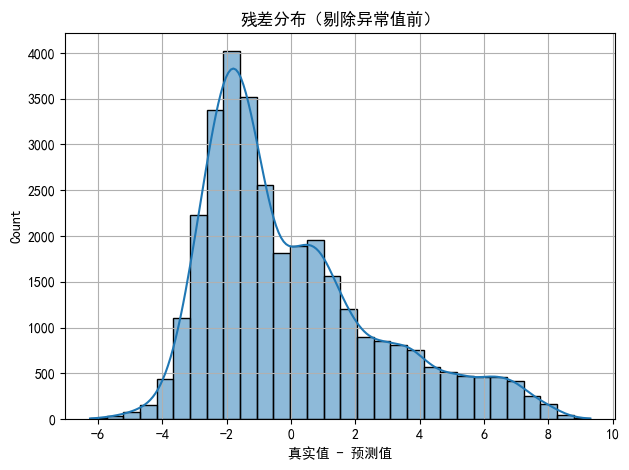

In [31]:
# 设置中文字体
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False

# === 模型定义 ===
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

# === Step 7: 初始训练 + 异常值检测 ===
print("🔍 训练初始模型计算训练误差，检测异常样本...")

stacking_model.fit(X_train_selected, y_train_winsorized)
train_preds = stacking_model.predict(X_train_selected)
residuals = np.abs(y_train_winsorized - train_preds)

# === 可视化：剔除前残差分布 ===
sns.histplot(y_train_winsorized - train_preds, bins=30, kde=True)
plt.title("残差分布（剔除异常值前）")
plt.xlabel("真实值 - 预测值")
plt.grid(True)
plt.tight_layout()
plt.savefig("D:\\desk file\\南开\\class2\\机器学习\\期末project\\Final\\figures\\图3_预测_vs_真实值.png", dpi=300)
plt.show()
plt.close()

Step8：剔除异常样本
1. 将训练集残差最大的 10% 样本作为异常值剔除，提升模型稳定性和泛化性能。
2. 创建清洗后的训练集：X_train_clean 和 y_train_clean。

In [32]:
threshold = np.percentile(residuals, 90)
outliers_idx = y_train_winsorized.index[residuals > threshold]
print(f"检测到 {len(outliers_idx)} 个异常样本（误差大于阈值 {threshold:.4f}）将被剔除")

X_train_clean = X_train_selected.drop(index=outliers_idx)
y_train_clean = y_train_winsorized.drop(index=outliers_idx)

检测到 3264 个异常样本（误差大于阈值 4.3742）将被剔除


Step9：使用交叉验证比较前后MSE
1. 手动实现交叉验证 MSE 的评估函数（使用 KFold）。
2. 比较：剔除前MSE和剔除后MSE。

这一步是用来验证“异常样本剔除”是否真的带来性能提升。

In [33]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_mse(model, X, y):
    mses = []
    for train_idx, val_idx in kf.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X.iloc[val_idx])
        mses.append(mean_squared_error(y.iloc[val_idx], preds))
    return np.mean(mses)

print("⏳ 计算剔除异常样本前的交叉验证 MSE...")
mse_before = cv_mse(stacking_model, X_train_selected, y_train_winsorized)
print(f"剔除异常样本前平均 MSE: {mse_before:.4f}")

print("⏳ 计算剔除异常样本后的交叉验证 MSE...")
mse_after = cv_mse(stacking_model, X_train_clean, y_train_clean)
print(f"剔除异常样本后平均 MSE: {mse_after:.4f}")

⏳ 计算剔除异常样本前的交叉验证 MSE...
剔除异常样本前平均 MSE: 9.3719
⏳ 计算剔除异常样本后的交叉验证 MSE...
剔除异常样本后平均 MSE: 4.8110


Step10：可视化剔除后的残差分布


📊 可视化剔除异常值后模型的残差分布...


findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

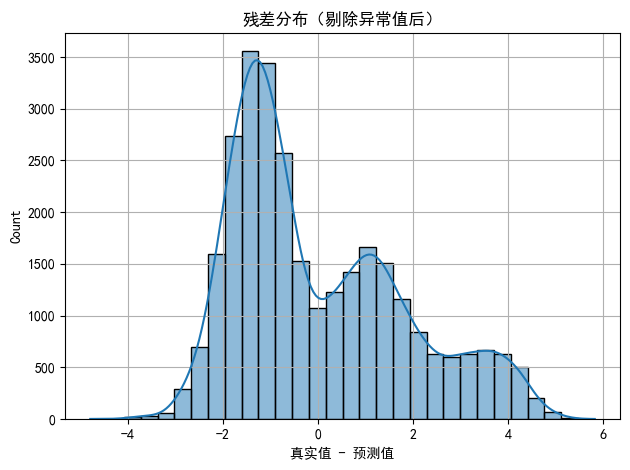

In [40]:
print("\n📊 可视化剔除异常值后模型的残差分布...")
stacking_model.fit(X_train_clean, y_train_clean)
clean_train_preds = stacking_model.predict(X_train_clean)
clean_residuals = y_train_clean - clean_train_preds

sns.histplot(clean_residuals, bins=30, kde=True)
plt.title("残差分布（剔除异常值后）")
plt.xlabel("真实值 - 预测值")
plt.grid(True)
plt.tight_layout()
plt.savefig("D:\\desk file\\南开\\class2\\机器学习\\期末project\\Final\\figures\\图4_预测_vs_真实值.png", dpi=300)
plt.show()
plt.close()

In [35]:
print("\n使用剔除异常样本后的训练集拟合最终模型，预测测试集...")
stacking_model.fit(X_train_clean, y_train_clean)
stacking_test_preds = stacking_model.predict(X_test_selected)

submission = pd.DataFrame({
    "Id": test_ids,
    "Hazard": stacking_test_preds
})
submission.to_csv("stacking_fusion_cleaned_submission_90%.csv", index=False)
print(" 剔除异常样本后 Stacking 融合预测完成，结果保存在 stacking_fusion_cleaned_submission_90%.csv") 


🚀 使用剔除异常样本后的训练集拟合最终模型，预测测试集...
✅ 剔除异常样本后 Stacking 融合预测完成，结果保存在 stacking_fusion_cleaned_submission_90%.csv



✅ 显示所有图像：


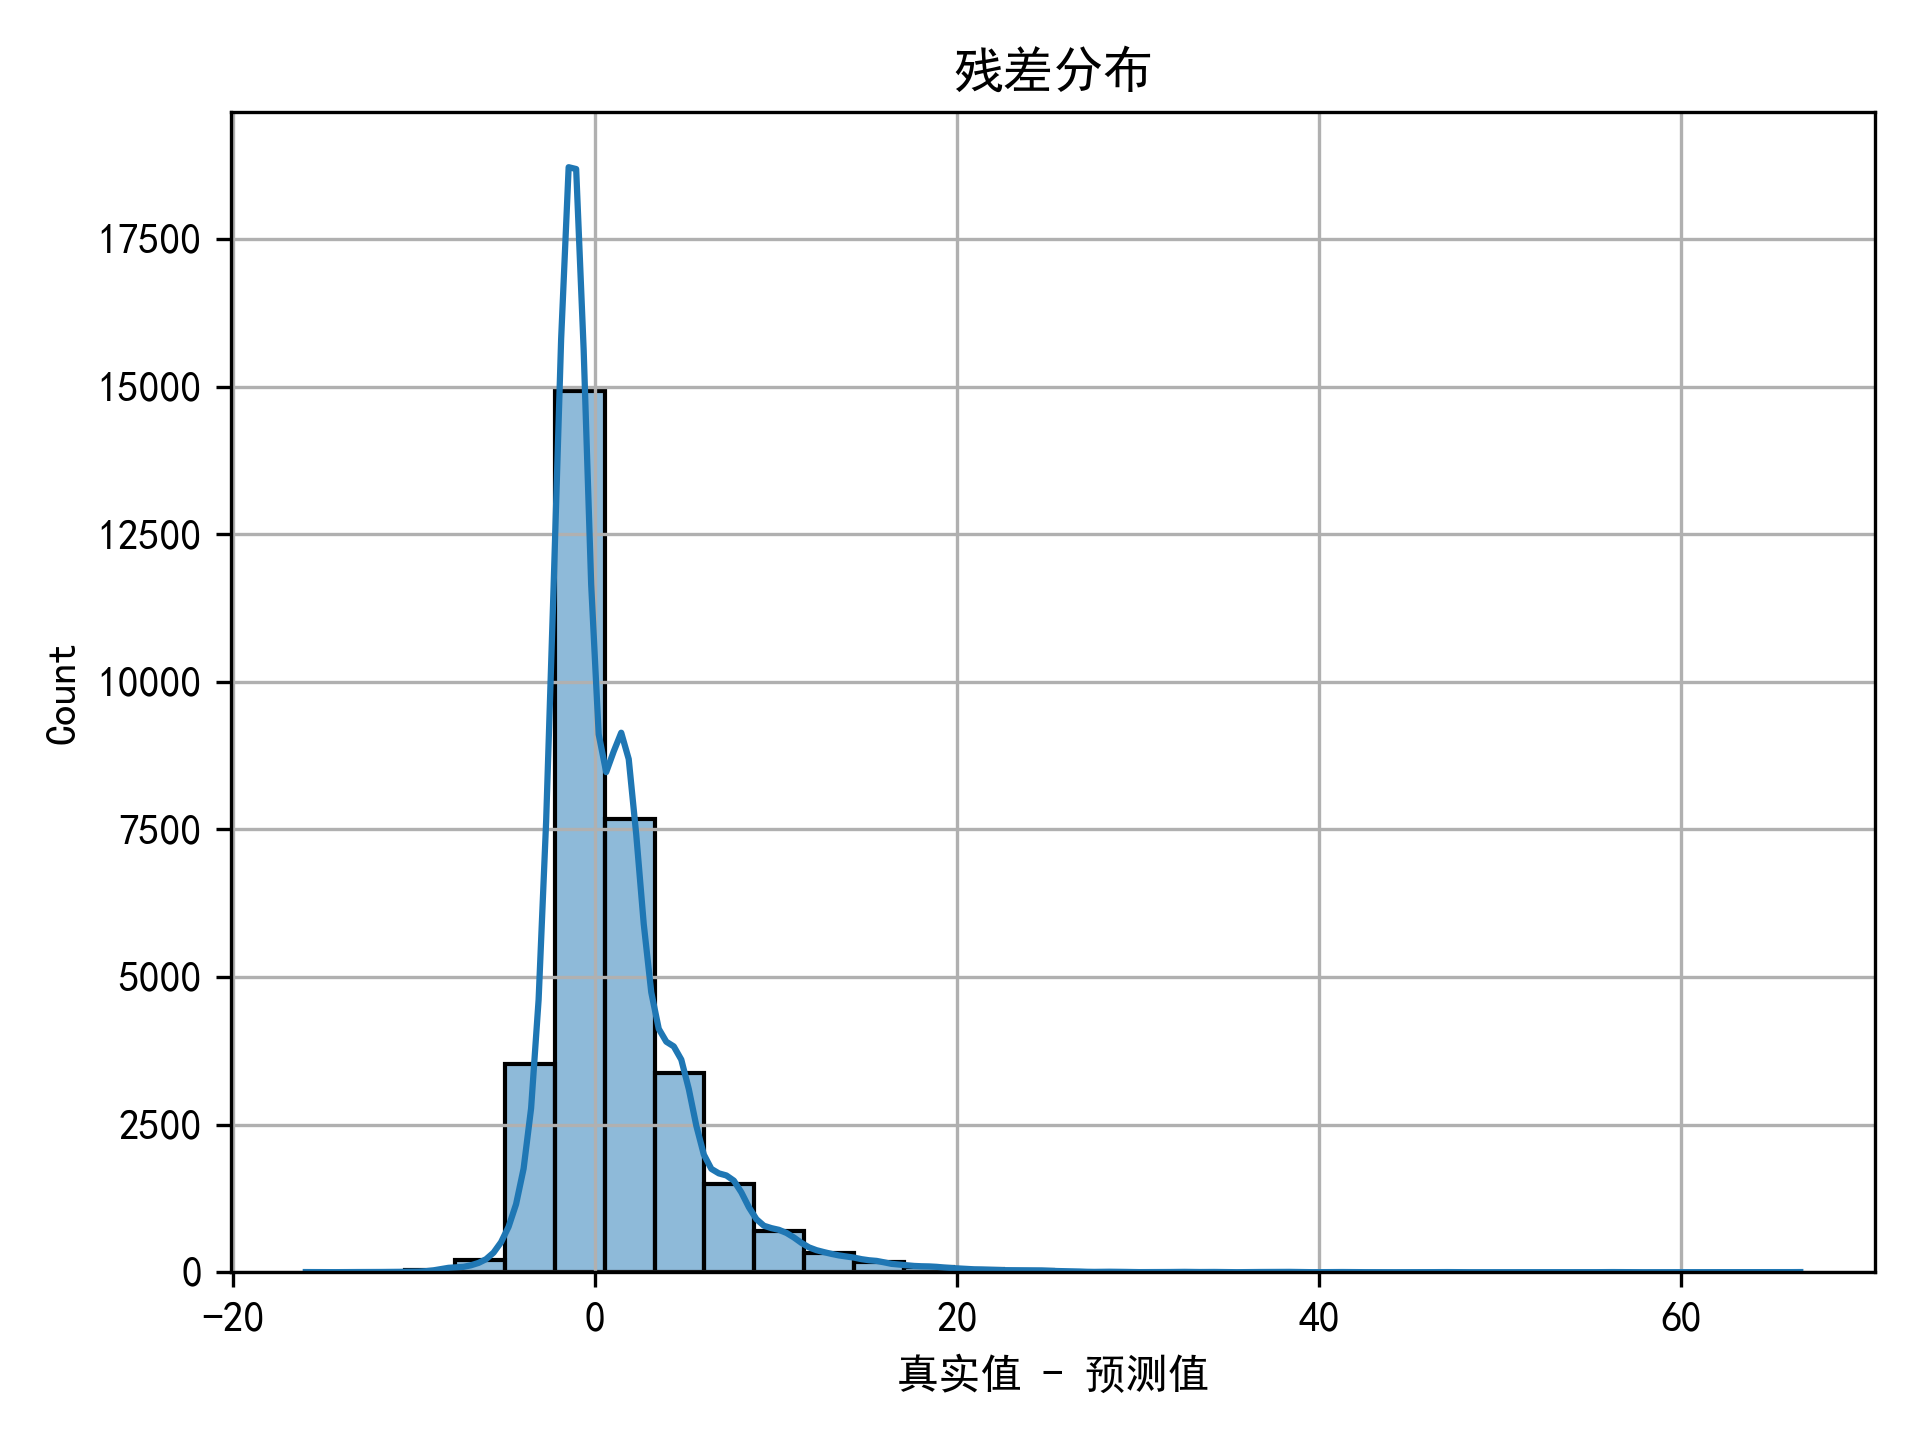

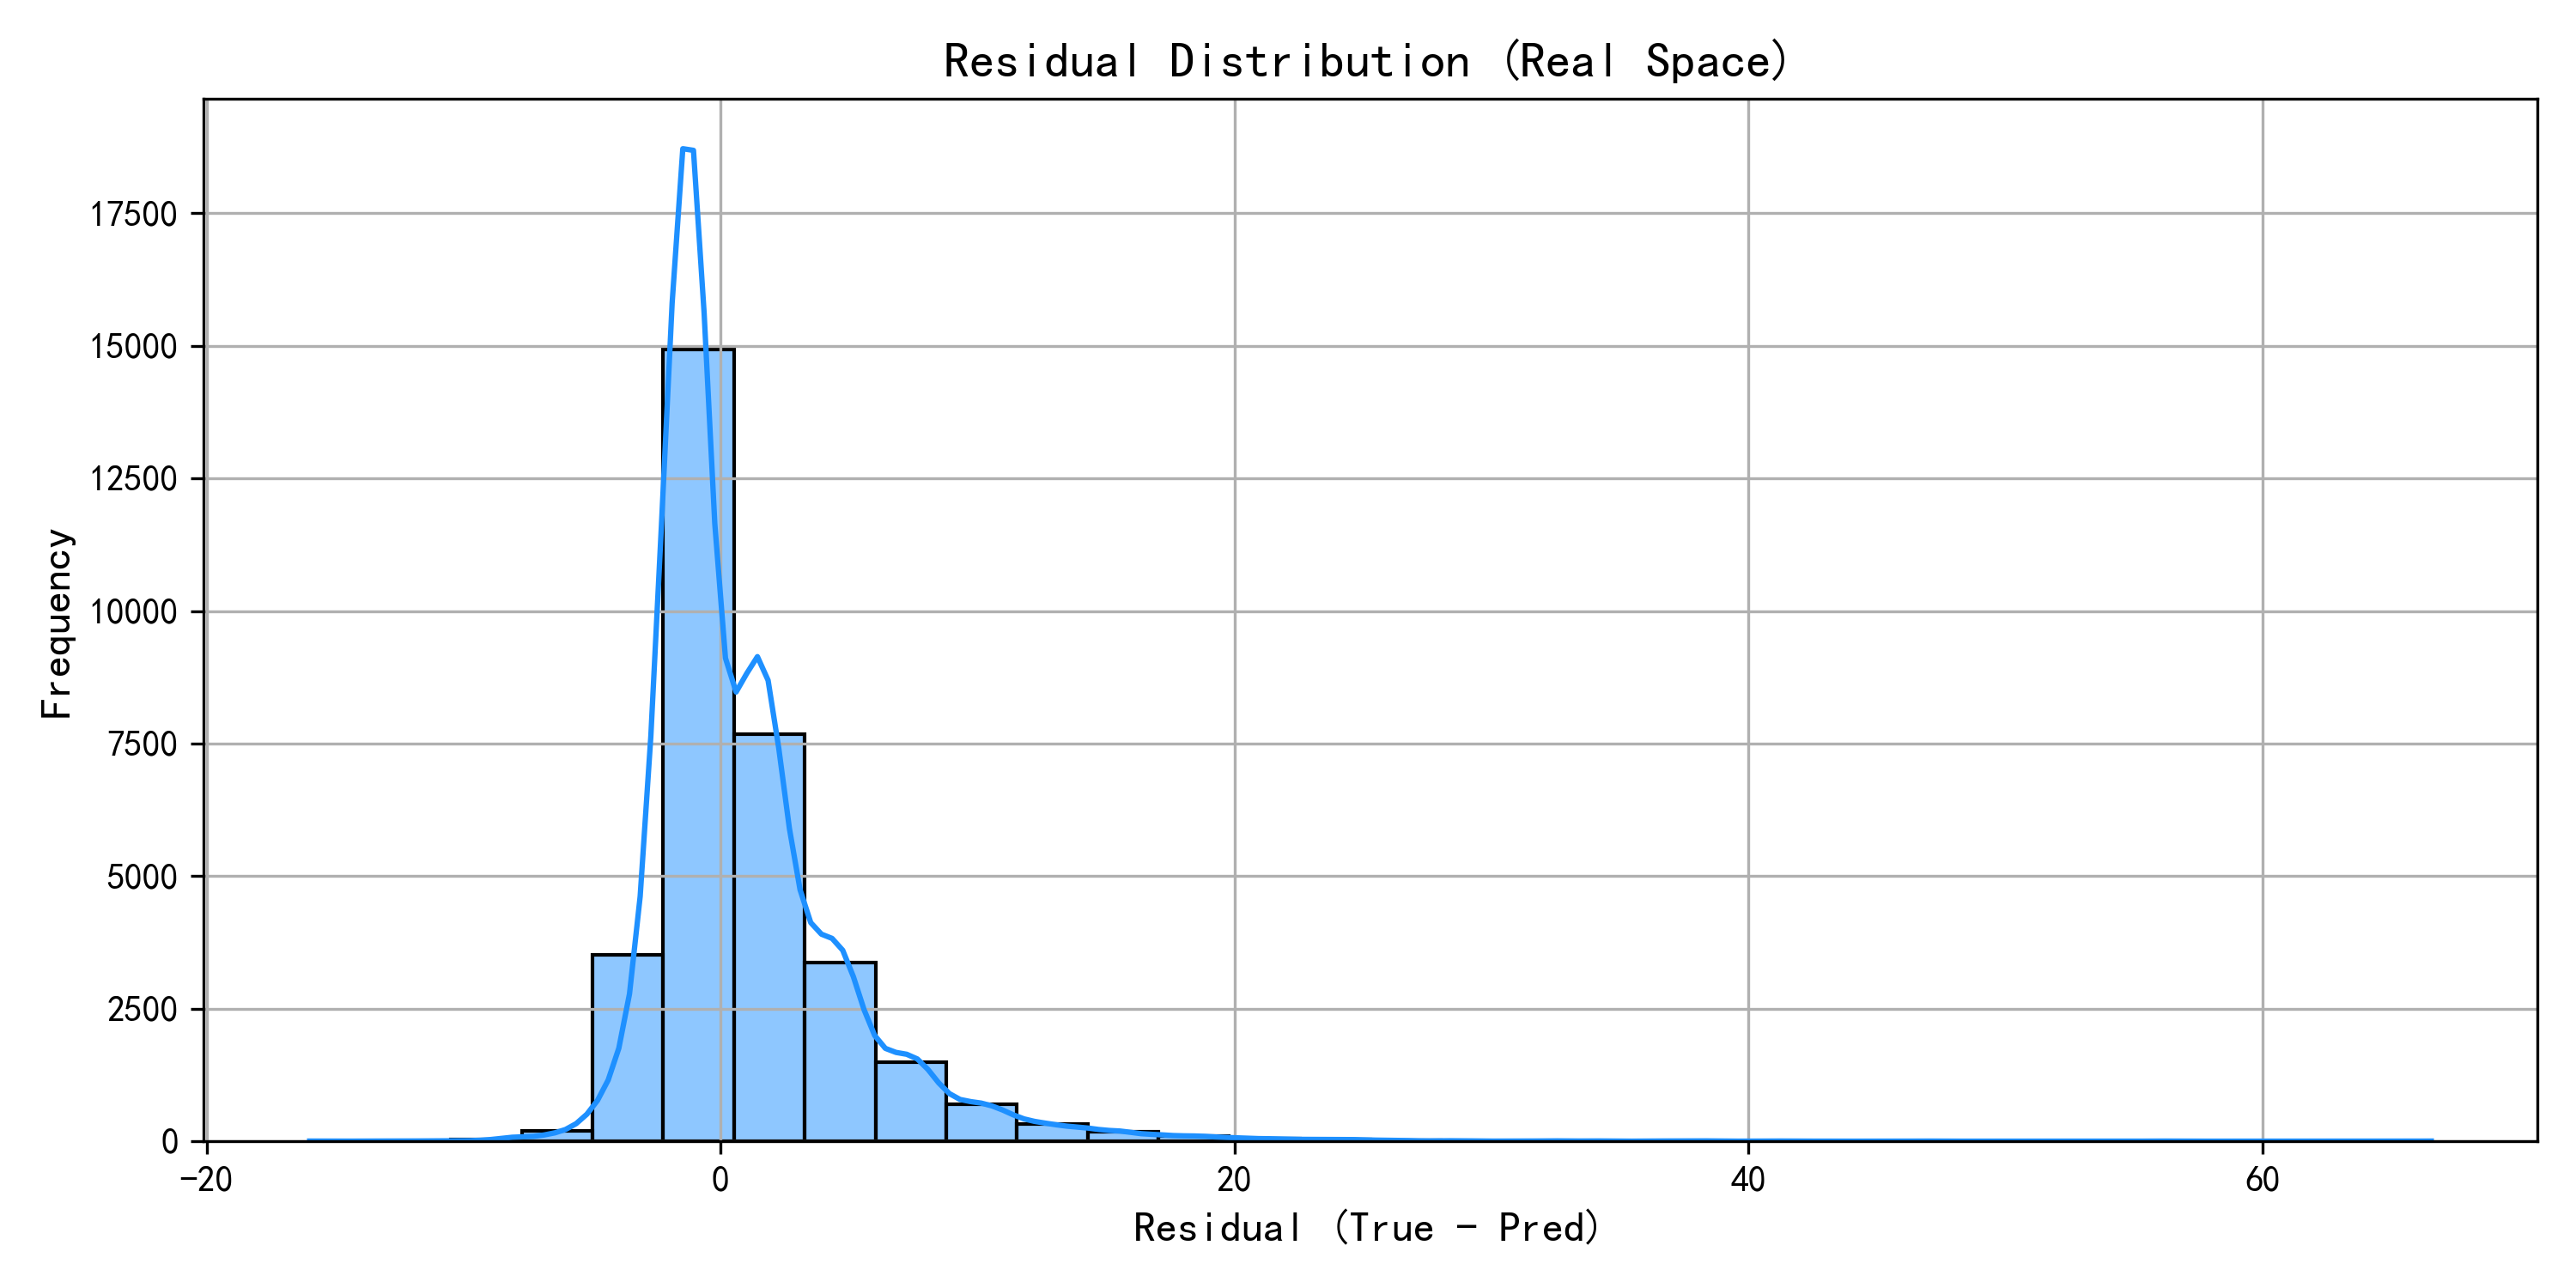

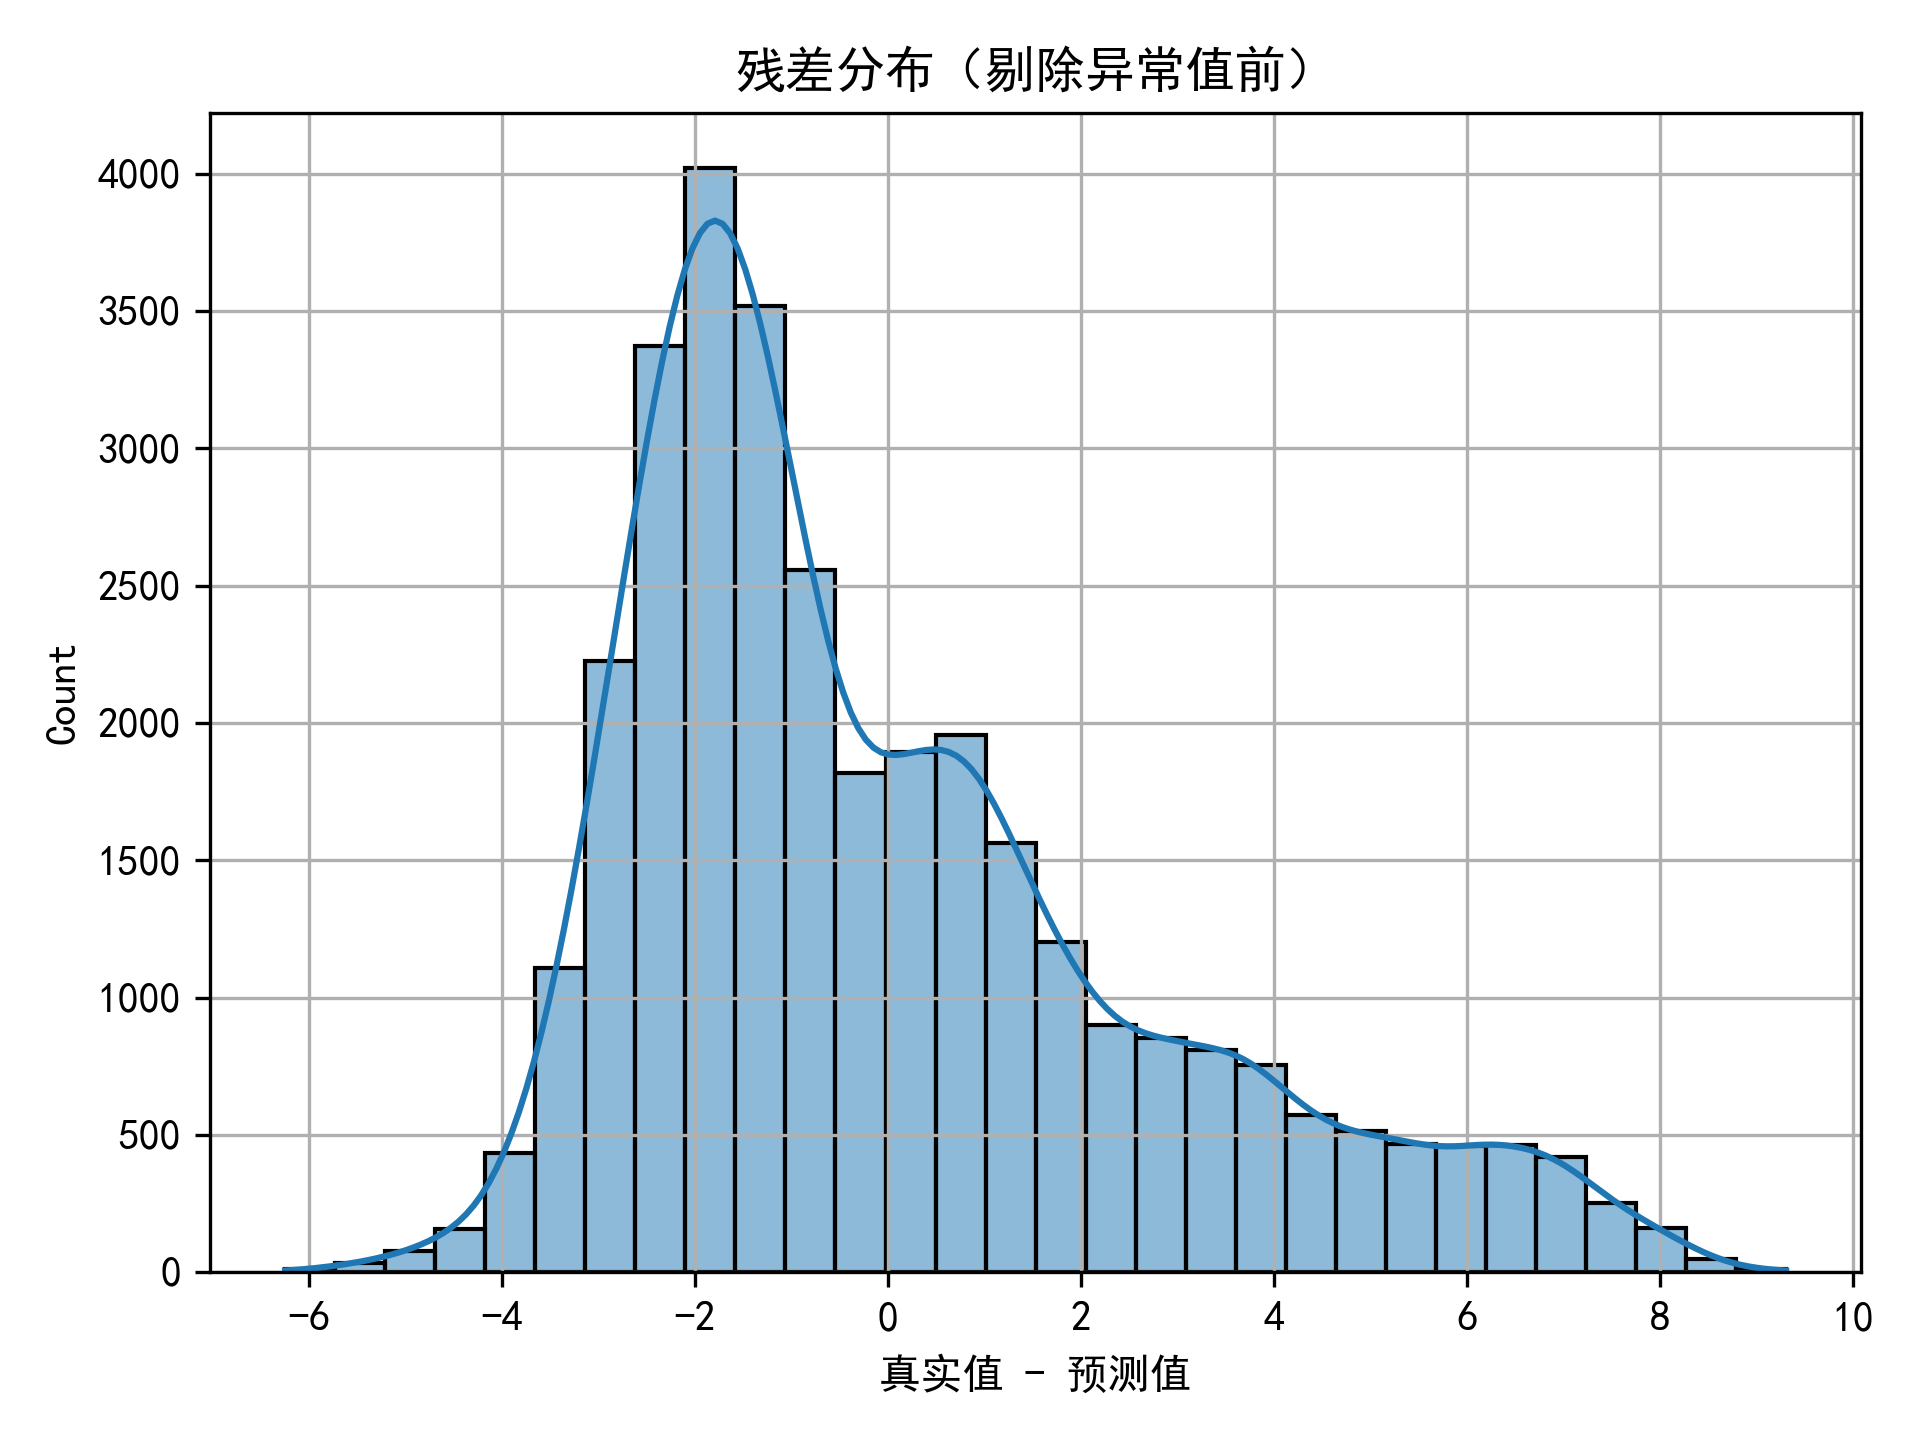

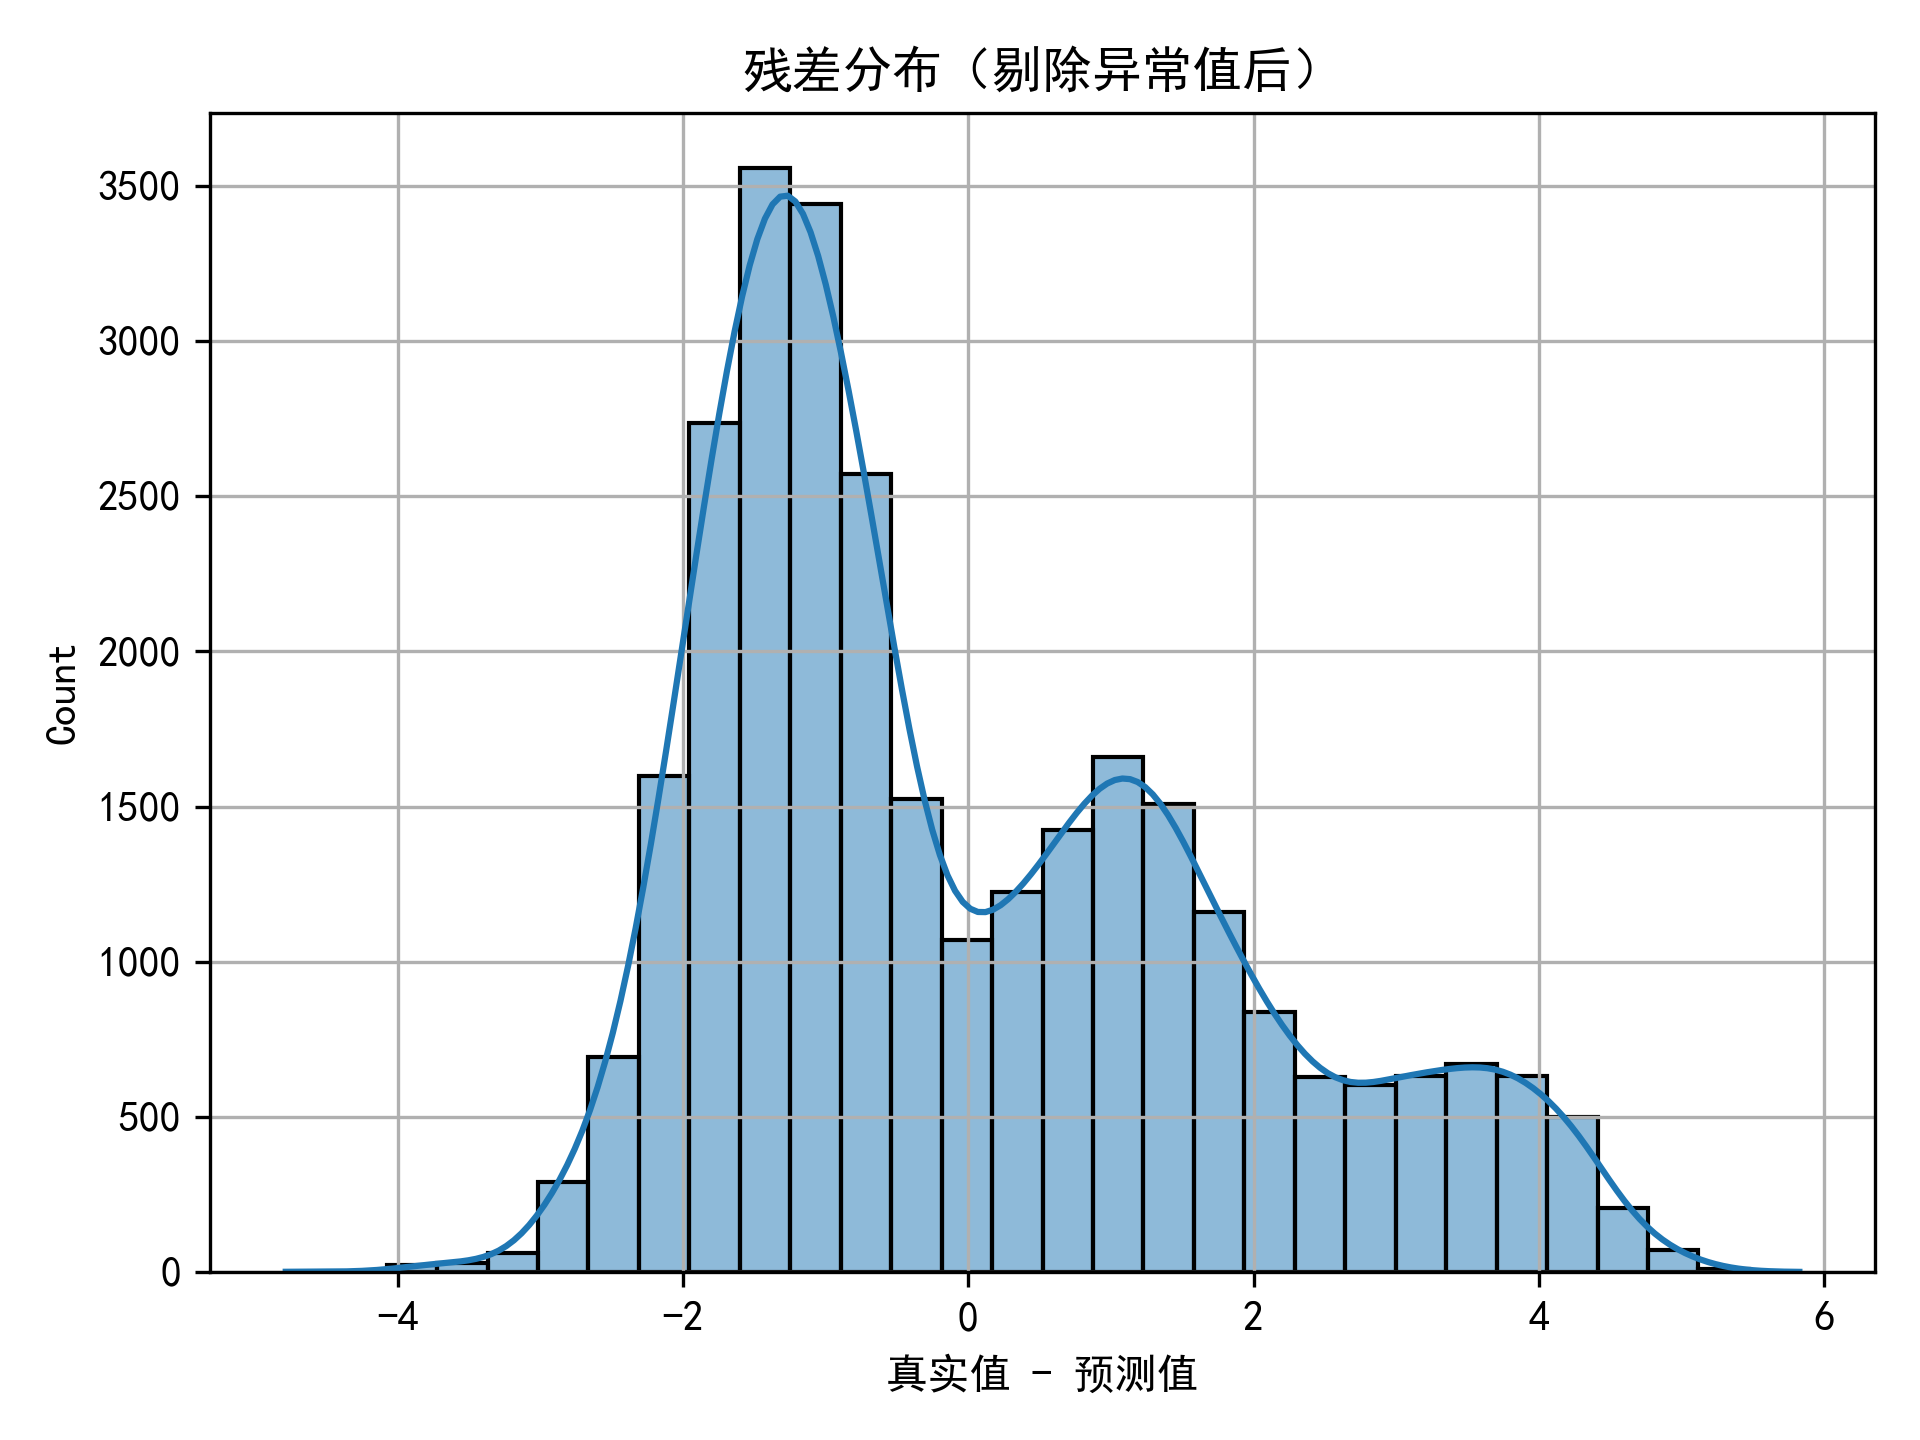

In [42]:
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import os
print("\n✅ 显示所有图像：")
for i in range(1, 5):
    img_path = f"figures/图{i}_*.png"
    # 自动获取文件名（防止路径写死）
    matched = [f for f in os.listdir("figures") if f.startswith(f"图{i}_")]
    if matched:
        display(IPImage(filename=os.path.join("figures", matched[0])))

# 结论基于残差分布与 MSE 的模型效果对比分析
结合 多阶段 Boosting 回归模型（模型 1） 和 Stacking 融合回归 + 异常值处理模型（模型 2） 的设计逻辑、残差分布特征及 MSE 数据，可从以下维度对比分析两者的预测效果：
1. 目标空间与预处理策略的差异

模型 1（多阶段 Boosting）：

对目标变量 Hazard 进行 对数变换（log 化），旨在缓解原始数据的右偏分布问题。其残差分析基于 log 空间（残差为 log(真实值) - log(预测值)），对应前两张残差图。log 化后，目标分布更接近正态，降低了模型拟合的非线性难度。

模型 2（Stacking 融合）：

对目标变量采用 Winsorization 缩尾处理（直接削弱原始数据的极端值），残差分析基于 原始空间（残差为 真实值 - 预测值），对应后两张残差图。该策略保留原始量纲，更直接反映实际预测误差。

2. 残差分布与异常值处理的效果

模型 1（log 空间，MSE：0.4114→0.2941）：

剔除 误差最大的 10% 样本 前，log 空间残差分布跨度大（横轴范围 -20~60），峰值两侧拖尾明显（如第一张图）；剔除后，残差分布更集中，曲线与直方图拟合更紧密（第二张图），MSE 从 0.4114 降至 0.2941。这说明：

（1）多阶段 Boosting（XGB+LGB 迭代学习残差）有效捕捉了 log 空间的误差模式；

（2）剔除预测误差大的样本，显著提升了模型在 log 空间的拟合精度。

模型 2（原始空间，MSE：9.3719→4.8110）：

剔除 残差最大的 10% 样本 前，原始空间残差分布分散（横轴范围 -6~10），极端残差拉低模型表现（MSE 9.3719，第三张图）；剔除后，残差区间收窄（-4~6），峰值更集中（第四张图），MSE 降至 4.8110。这验证了：

（1）Stacking 融合（线性 + 树模型 + SVR）覆盖了复杂非线性模式，初步降低误差；

（2）Winsorization 缩尾 + 残差异常值剔除的双重策略，有效抑制了极端值对模型的干扰。

In [ ]:
import pandas as pd

# 读取文件
df = pd.read_csv("D:\\desk file\\南开\\class2\\机器学习\\第七组+戎晓媛\\第七组+戎晓媛\\中间数据\\模型2_submission.csv")

# 将Hazard列直接转换为整数（去除小数部分）
df['Hazard'] = df['Hazard'].astype(int)

# 保存为新文件
df.to_csv('模型2final_submission_hazard_int.csv', index=False)
